# Resultados finais congelados

Visualização do run final executado sem refit ou recalibração. O gate deve permanecer fechado.

In [1]:
import json
from pathlib import Path

import pandas as pd
import yaml
from IPython.display import Image, display

ROOT = Path.cwd() if (Path.cwd() / 'results').is_dir() else Path.cwd().parent
RUN = ROOT / 'results/runs/20260721-024728_final-test-k5_68bd89db'
FIGURES = ROOT / 'figures/final_test_v2'
manifest = json.loads((RUN / 'manifest.json').read_text())
gate = yaml.safe_load((ROOT / 'configs/final_test.yaml').read_text())
assert manifest['final_test_used'] is True
assert manifest['no_refit_or_recalibration'] is True
assert gate['status'] == 'completed_locked' and gate['allow_test'] is False


In [2]:
pd.read_csv(FIGURES / 'subset_metrics.csv').round(3)


,subset,rows,positive,prevalence,roc_auc,pr_auc,brier,ece,aurc,balanced_coverage,balanced_risk,balanced_f1
0,official_dev,310,105,0.339,0.744,0.604,0.195,0.082,0.478,0.416,0.457,0.598
1,dev_clean_exact,288,91,0.316,0.742,0.583,0.194,0.092,0.505,0.410,0.483,0.584
2,dev_clean_near,267,83,0.311,0.738,0.574,0.195,0.099,0.513,0.408,0.486,0.583


In [3]:
pd.read_csv(FIGURES / 'retrieval_metrics.csv').round(3)


,method,mrr,context_recall_at_1,ndcg_at_1,context_recall_at_3,ndcg_at_3,context_recall_at_5,ndcg_at_5,context_recall_at_10,ndcg_at_10
0,bm25,0.470,0.344,0.344,0.581,0.481,0.625,0.497,0.656,0.507
1,semantic,0.496,0.369,0.369,0.562,0.484,0.631,0.513,0.744,0.548
2,hybrid,0.531,0.419,0.419,0.606,0.527,0.656,0.548,0.744,0.576


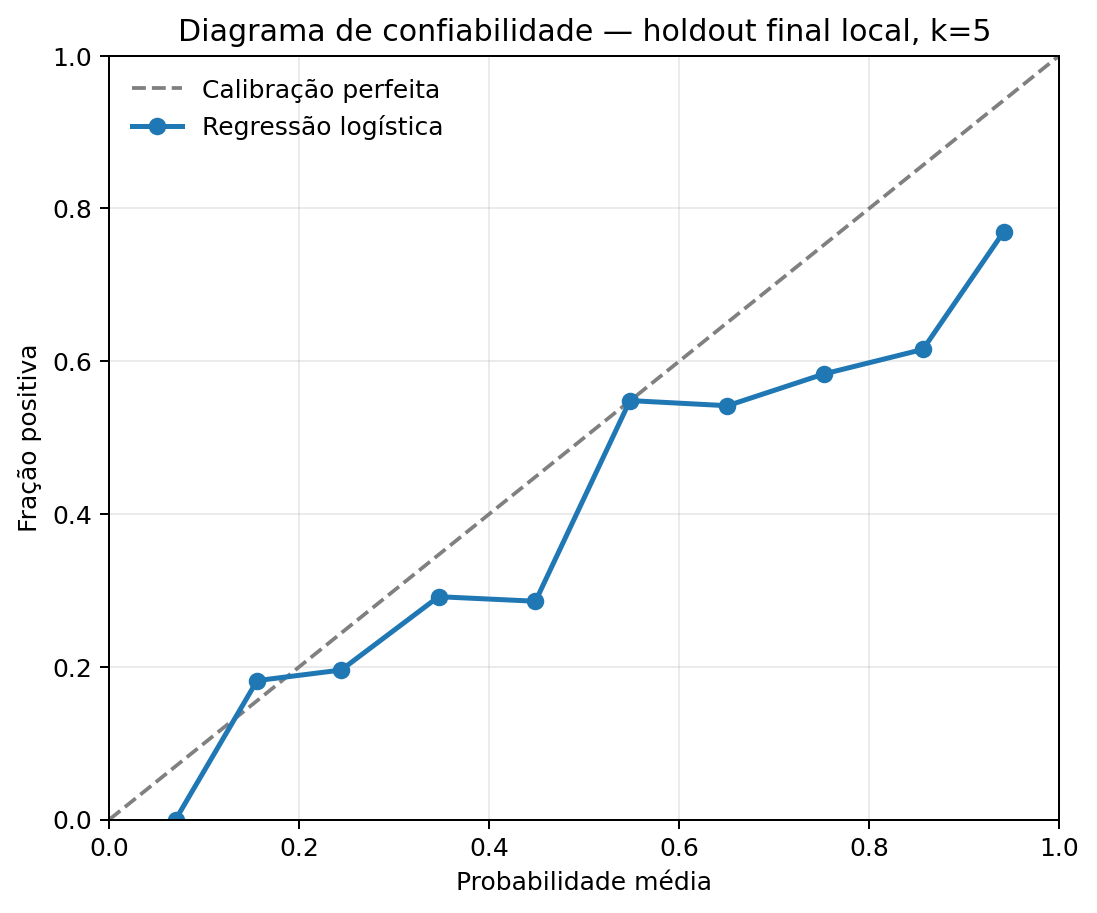

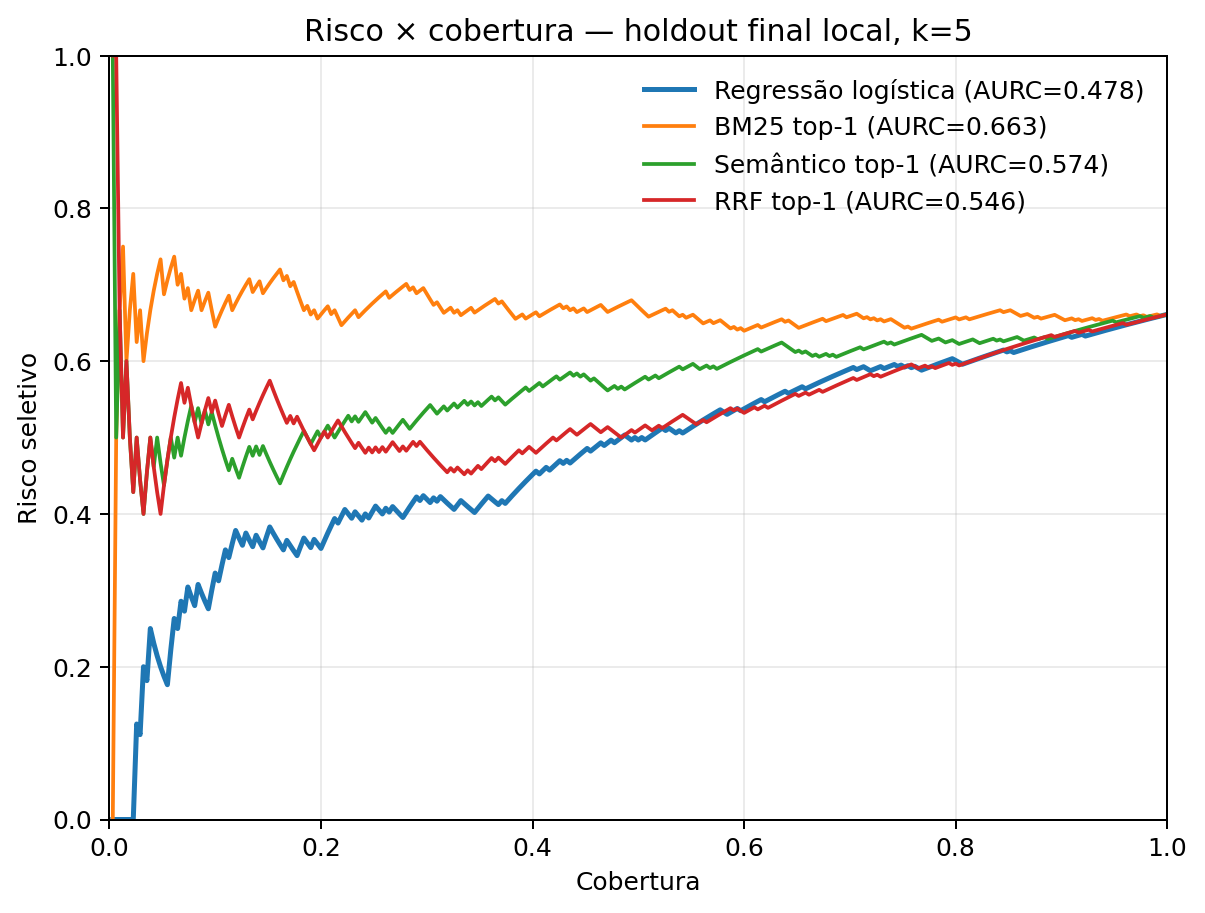

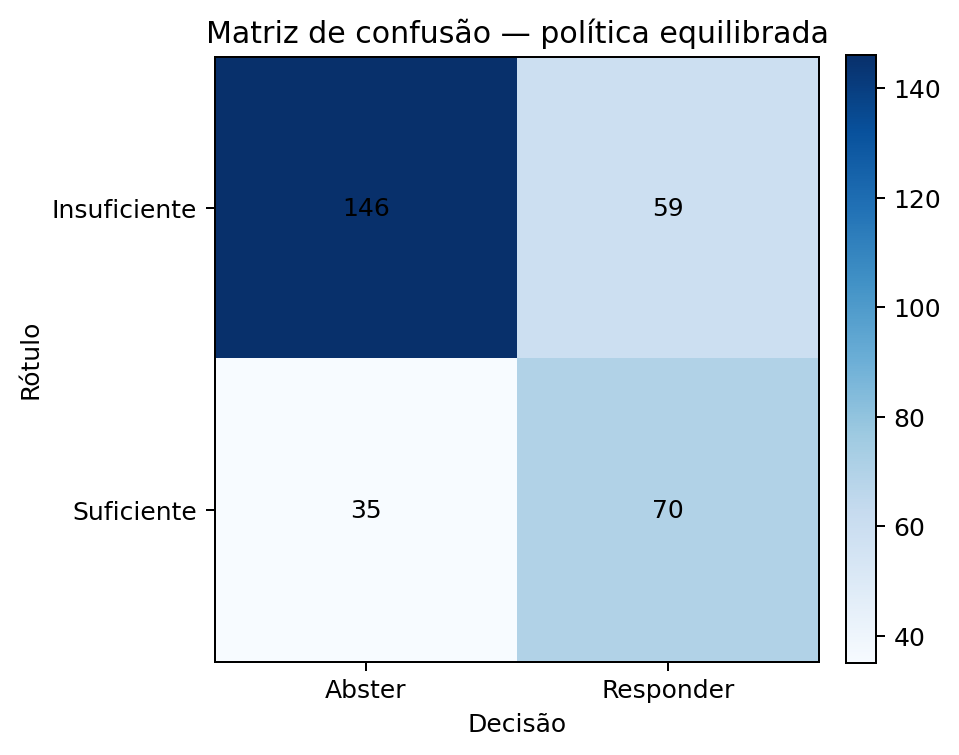

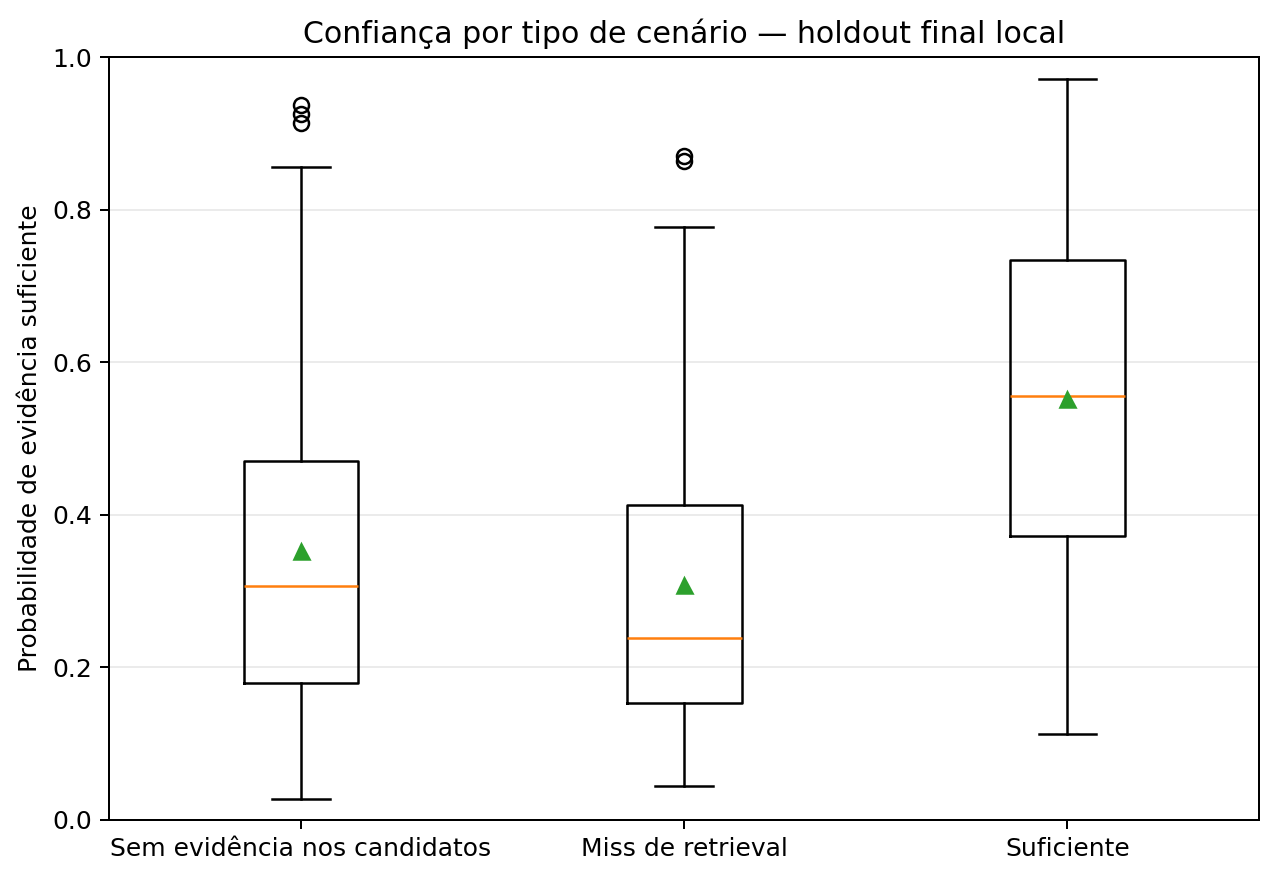

In [4]:
for name in ['reliability_final.png', 'risk_coverage_final.png', 'confusion_balanced_final.png', 'scenario_probabilities_final.png']:
    display(Image(filename=FIGURES / name, width=760))


## Conclusão

A combinação confirmou ganho de PR-AUC sobre RRF, mas não confirmou vantagem em ROC-AUC ou AURC. Os riscos das políticas internas não se transferiram ao holdout; a hipótese recebeu apoio parcial.